# Random Processes and Monte Carlo Methods

See examples/probabilty_example.ipynb for an example of how to use random number generation to model probabilities.

**Authorship information:** Parts 1 and 2 of this notebook were written by the instructor with some assistance by Github Copilot (autocomplete). Part 3 was developed iteratively with Claude.ai, a large language model, for PHY 225 taught by Prof. Bryanne McDonough. The LLM was asked to develop a problem that combined radioactive decay and random walks. Prof. McDonough reviewed and refined the content.

Both humans and LLMs can (and will) make mistakes. Please raise an issue on the upstream GitHub repository (the one you forked) if you find a problem.

## Grading

Note that for this assignment there are three parts. To achieve a good grade on this assignment, it is only necessary to complete parts 1 and 2. However, to earn a score of 'Advanced', you must also complete Part 3. If you find that Parts 1 and 2 take you a long time, it might be better to skip Part 3 and work on your projects instead.

Your assignment will be graded on the following scale:
- **No Evidence** — assignment not completed or submitted
- **Beginning** — some effort, but significant errors or omissions
- **Emerging** — mostly correct, but with some errors or omissions
- **Proficient** — correct and complete, with clear explanations (Parts 1 and 2 complete)
- **Advanced** — correct, complete, and demonstrates deeper understanding (Part 3 completed in addition to parts 1 and 2)


## Part 1: Radioactive Decay
The radioisotope Carbon-14 decays with a half-life of 5730 years. This means that if you start with a sample of Carbon-14, after 5730 years, only half of the original sample will remain. The decay product is Nitrogen-14, which is stable.

The number of Carbon-14 atoms remaining after time *t* can be modeled as an exponential decay process:
$$
N(t) = N_0 2^{-t/\tau},
$$
where $N_0$ is the initial number of Carbon-14 atoms and $\tau$ is the half-life.

The fraction of C14 atoms remaining after some time *t* can be calculated as: $\frac{N(t)}{N_0} = 2^{-t/\tau}$. Thus, the fraction of C14 atoms that have decayed is $1 - 2^{-t/\tau}$. This is then the probability for an individual C14 atom to have decayed:
$$
p=  1 - 2^{-t/\tau}
$$


### Exercise 1: Simulating Radioactive Decay
Write a program which does the following:
1. Starts with a sample of 1000 Carbon-14 atoms and 0 Nitrogen-14 atoms.
2. Iterates over 50,000 years in increments of 1,000 years.
3. At each time step, iterate (or use vector operations) over each remaining C14 atom to determine whether or not it decays. 
4. At each timestep, update the counts of C14 and N14 atoms accordingly.
5. Plots the number of C14 and N14 atoms as a function of time.

In [1245]:
import numpy as np
import matplotlib.pyplot as plt

In [1246]:
#write your program for exercise 1 here

tau = 5730 # Decay constant for C14 in years
timeline = np.linspace(0, 50000, 50) # Time points from 0 to 50,000 years
N = 5000 # Initial number of C14 atoms


In [1247]:
prob_of_decay = 1 - 2 ** (-1000 / tau) # Calculate the probability of decay for each time point in the timeline

outcomes = np.random.rand(N, len(timeline)) < prob_of_decay # Generate a 2D array of random numbers and compare to the probability of decay to determine if each atom decays at each time point

outcomes[:, 0] = False # Set the initial state of all atoms to not decayed at time 0

for t in range(len(timeline)):
    for i in range(N): # Loop over each time point and count the number of decayed atoms
        if outcomes[i, t]: # If the atom decays at this time point
            outcomes[i, t:] = True # Increment the count of decayed atoms for this time point

outcomes = np.where(outcomes, 0, 1) # Get the indices of the decayed atoms at each time point

N_C14 = np.sum(outcomes, axis=0) # Count the number of C14 atoms remaining at each time point
N_N14 = N - N_C14 # Calculate the number of N14 atoms produced at each time point

    

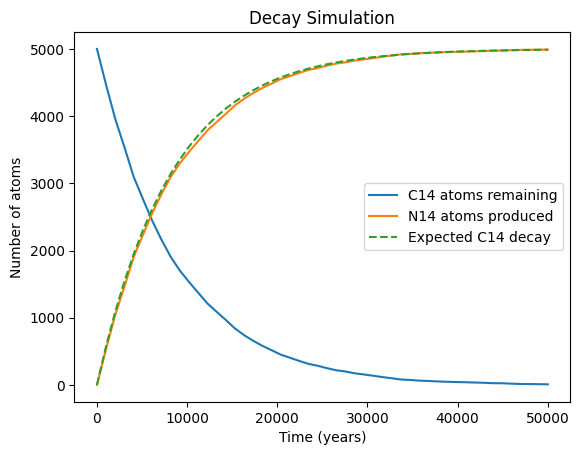

In [1248]:
plt.figure()
plt.plot(timeline, N_C14, label='C14 atoms remaining')
plt.plot(timeline, N_N14, label='N14 atoms produced')
plt.plot(timeline, (N * (1 - 2 ** (-timeline / tau))), label='Expected C14 decay', linestyle='dashed') # Plot the expected decay curve for comparison
plt.xlabel('Time (years)')
plt.ylabel('Number of atoms')
plt.title('Decay Simulation')
plt.legend()
plt.show()

## Part 2: Random Walks
Brownian motion is the random movement of particles suspended in a fluid (liquid or gas) resulting from their collision with the fast-moving molecules in the fluid. This phenomenon can be modeled as a random walk, where a particle takes steps in random directions at each time step. In a simple 2D random walk, a particle can move up, down, left, or right with equal probability.

### Exercise 2: Simulating a 2D Random Walk
Write a program that simulates a 2D random walk of a single particle. The program should:
1. Set up a grid of L x L points (e.g., L=101, you will want an odd number so there is a center point). The particle is initially located at the center of the grid and must stay within the bounds of the grid.
2. At each step, use a  random number generator to randomly choose a direction (up, down, left, right) and move the particle one unit in that direction. If the move would make the particle go out of bounds, ignore that move and choose another random direction.
3. Repeat this process for a large number of steps (e.g., 10,000 steps).
4. After the simulation, plot the trajectory of the particle on the grid.
    - Make sure your plot has labeled axes
    - Make sure your plot includes the trajectory and clearly labeled points for the starting and ending positions of the particle.
    - When you plot the trajectory, use the linewidth parameter to make the line thinner (lw=0.4), so the plot is easier to read. You may also want to reduce the opacity (using alpha=0.5).



In [1249]:
# write your random walk code here

In [1250]:
position = np.array([50, 50]) # Initialize the position of the random walk at the origin

path = np.array([50, 50]) # Initialize a list to store the positions at each step of the random walk

l = 0

steps = 10000 # Set the target distance for the random walk to reach from the origin

while l != steps: # Loop until the random walk reaches a distance of 10,000 units from the origin
    step = np.random.choice([1, 2, 3, 4]) # Randomly choose a step in one of the four cardinal directions

    if step == 1 and position[0] != 101: # If the step is in the positive x direction
        position[0] += 1 # Update the position by moving one unit in the positive x direction
    
    elif step == 2 and position[0] != 0: # If the step is in the negative x direction
        position[0] -= 1 # Update the position by moving one unit in the negative x direction
    
    elif step == 3 and position[1] != 101: # If the step is in the positive y direction
        position[1] += 1 # Update the position by moving one unit in the positive y direction
    
    elif step == 4 and position[1] != 0: # If the step is in the negative y direction
        position[1] -= 1 # Update the position by moving one unit in the negative y direction
    
    else:
        continue # If the step would take the position out of bounds, skip this iteration and choose a new step
    
    l += 1 # Increment the step count

    path = np.vstack([path, position]) # Append the current position to the list of positions
        

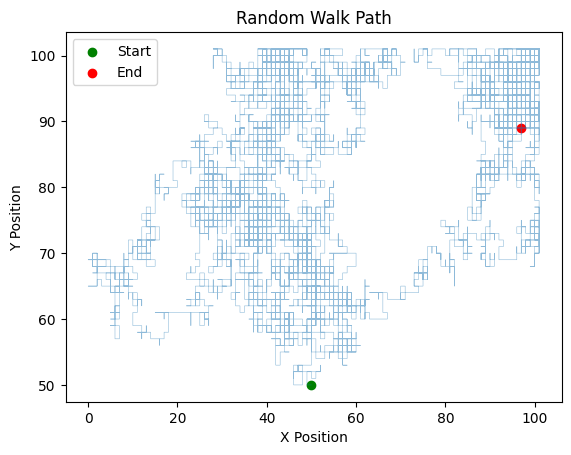

In [1251]:
plt.figure()
plt.plot(path[:, 0], path[:, 1], lw = 0.4, alpha = 0.5) # Plot the path of the random walk
plt.scatter(path[0, 0], path[0, 1], color = 'green', label='Start') # Mark the starting point
plt.scatter(path[-1, 0], path[-1, 1], color='red', label='End') # Mark the ending point
plt.xlabel('X Position')
plt.ylabel('Y Position')
plt.title('Random Walk Path')
plt.legend()
plt.show()

## Part 3: Radon-222 Diffusion and Escape
**You only need to do this part for an ADVANCED grade.**

Radon-222 is a naturally occurring radioactive noble gas produced by the decay
of uranium and radium in soil and rock. Because it is chemically inert, it
diffuses freely through soil pore spaces — unlike its decay daughters (Po-218,
Pb-214, Bi-214), which are solid metals that immediately plate out onto soil
grains upon formation and can be treated as immobile.

Each Rn-222 atom therefore has exactly one of three fates:
1. **Decays in the soil** — daughter products are immobilized; no atmospheric hazard
2. **Escapes at the surface** — enters indoor air, where short-lived daughters
   become a lung-cancer hazard
3. **Still diffusing** — fate not yet determined



### Exercise 3: Simulating Radon Diffusion and Escape
1. Model the soil as an $L \times L$ grid with **asymmetric boundary conditions**:
   - The **top row** is an absorbing boundary representing the soil-air interface:
  any atom that reaches it should be removed from the simulation and recorded as escaped.
   - The **other three sides** are reflecting boundaries representing bedrock or
  symmetric soil: any attempted move out of bounds should be rejected and redrawn. ("Symmetric soil" here means that we essentially assume there are particles not in the grid that can enter the grid, and those will balance out with any particles that leave on those sides.)
2. Use a half-life of $\tau = 3.82$ days for Rn-222, and work in units of hours. Start with 2000 Rn-222 atoms randomly distributed in the grid. 
3. Set a time step of $\Delta t = 6$ hours and run the simulation for 480 hours (~20 days, or ~5 half-lives).
4. At each time step, iterate over each remaining Rn-222 atom to determine whether it decays (with probability $p = 1 - 2^{-\Delta t/\tau}$) or moves (with probability $1-p$). If it moves, randomly choose a direction and move the atom accordingly, applying the appropriate boundary conditions.
5. Plot the number of Rn-222 atoms remaining in the soil, the number of Rn-222 atoms that have decayed in the soil, and the number that have escaped to the atmosphere as a function of time. 

In [1252]:
#write code for exercise 3 here

In [1253]:
tau = 3.82 # Decay constant for Rn-222 in days
N = 2000 # Initial number of Rn-222 atoms
L = 101 # Define the size of the box for the random walk
states = L * np.random.rand(4, N)
p_decay = 1 - 2 ** (-(6/24) / tau) # Calculate the probability of decay

states[2:4, :] = False # Set the initial state of all atoms to not decayed at time 0

In [ ]:
steps = 480 // 6 # Set the target distance for the random walk to reach from the origin

status = np.zeros((2, N, steps + 1)) # Initialize a 3D array to store the status of each atom at each time step

for n in range(N): # Loop over each atom

    l = 0 # Initialize the step count for this atom

    while l != steps: # Loop until end of sim

        if np.random.rand() < p_decay: # Check if the atom decays at this time step
            states[2, n] = True # Mark the atom as decayed
            
            status[0, n, l + 1:] = states[2, n] # Store the decay status of the atom at this time step

            break

        elif states[2, n] == False and states[3, n] == False: # If the atom has not decayed or escaped
            step = np.random.choice([1, 2, 3, 4]) # Randomly choose a step in one of the four cardinal directions

            if step == 1 and states[0, n] <= L - 1: # If the step is in the positive x direction
                states[0, n] += 1 # Update the position by moving one unit in the positive x direction
        
            elif step == 2 and states[0, n] >= 0 + 1: # If the step is in the negative x direction
                states[0, n] -= 1 # Update the position by moving one unit in the negative x direction
        
            elif step == 3 and states[1, n] <= L - 1: # If the step is in the positive y direction
                states[1, n] += 1 # Update the position by moving one unit in the positive y direction
        
            elif step == 4 and states[1, n] >= 0 + 1: # If the step is in the negative y direction
                states[1, n] -= 1 # Update the position by moving one unit in the negative y direction

            elif step == 3 and states[1, n] > L - 1: # If the step is in the positive y direction and the atom is at the upper boundary
                states[3, n] = True # Mark the atom as escaped
                status[1, n, l + 1:] = states[3, n] # Store the escape status of the atom at this time step
                break

            else:
                continue # If the step would take the position out of bounds, skip this iteration and choose a new step
        
            l += 1 # Increment the step count for this atom

In [1255]:
decay_counts = np.sum(status[0, :, :], axis=0) # Count the number of decayed atoms at each time step
escape_counts = np.sum(status[1, :, :], axis=0) # Count the number of escaped atoms at each time step
soil_counts = N - decay_counts - escape_counts # Calculate the number of atoms still in the soil at each time step  
decay_counts[-1], escape_counts[-1], soil_counts[-1]

(np.float64(1915.0), np.float64(44.0), np.float64(41.0))

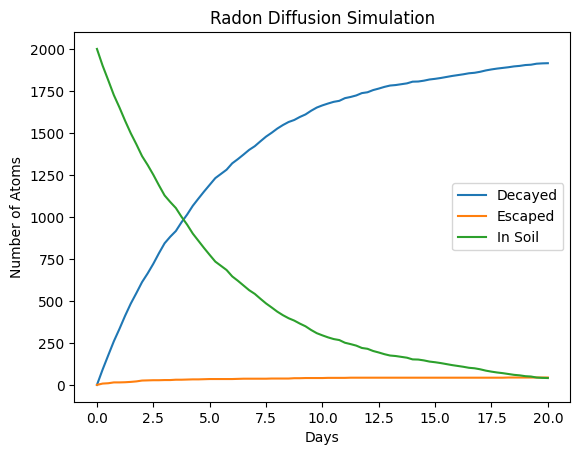

In [1257]:
timeline = np.linspace(0, 20, steps + 1) # Create a timeline for the x-axis of the plot

plt.figure()
plt.plot(timeline, decay_counts, label='Decayed')
plt.plot(timeline, escape_counts, label='Escaped')
plt.plot(timeline, soil_counts, label='In Soil')

plt.xlabel('Days')
plt.ylabel('Number of Atoms')
plt.title('Radon Diffusion Simulation')
plt.legend()
plt.show()